LOADING THE DATASET

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("D:/deepthi-files/mini-project/data.csv",encoding="ISO-8859-1")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


DATA UNDERSTANDING

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

The dataset contains 5,41,909 records and 8 features, which shows it is a large-scale real-world retail dataset.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


The dataset has mixed data types with missing values in Description and CustomerID, and InvoiceDate needs type conversion for time-based analysis.

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Only Description and CustomerID contain missing values, with CustomerID having a large number of missing entries.

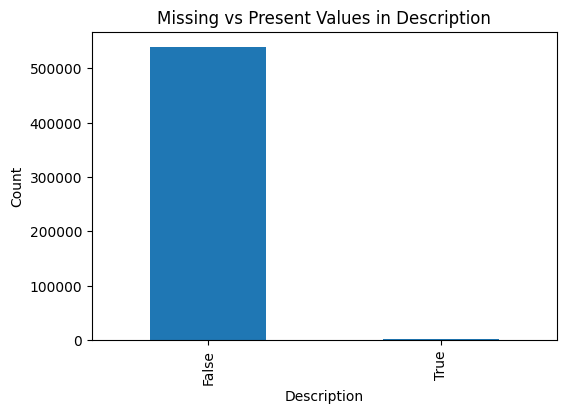

In [6]:
plt.figure(figsize=(6,4))
df['Description'].isnull().value_counts().plot(kind='bar')
plt.title("Missing vs Present Values in Description")
plt.ylabel("Count")
plt.show()


Some records had missing values in the Description column.

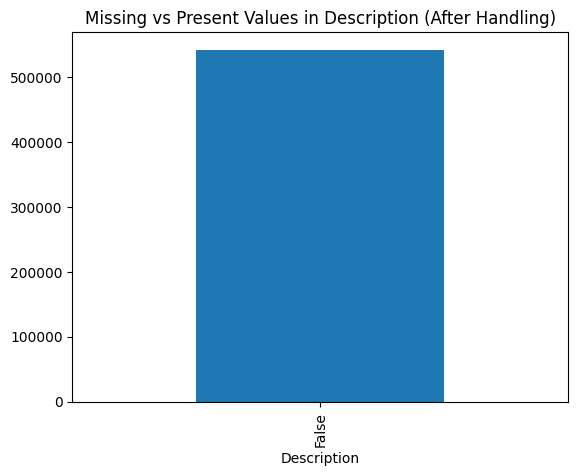

In [7]:
#HANDLING MISSING VALUES
df['Description'] = df['Description'].fillna("unknown")
df['Description'].isnull().value_counts().plot(kind='bar')
plt.title("Missing vs Present Values in Description (After Handling)")
plt.show()


==> Mode filling gives many missing rows the same product name, which makes that product look more popular than it really is. To avoid this wrong impression, missing descriptions were filled with “Unknown” instead.
==> Suppose the most common product is “WHITE HANGING HEART T-LIGHT HOLDER”.
If 1,454 missing descriptions are filled with this,
that product will suddenly appear 1,454 times more popular than it really is.

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df_all = df.copy()
df_cust = df.dropna(subset=['CustomerID']).copy()

We created two datasets for analysis. 
One dataset keeps all the records and is used to study sales trends, products, and time-based patterns. Missing product names were filled with “Unknown” so that no data is lost. 
The second dataset contains only the records that have CustomerID and is used only for customer analysis. This helps us avoid losing sales data and also ensures that customer-related results are correct and reliable.

In [10]:
df_all.shape, df_cust.shape

((541909, 8), (406829, 8))

We kept all 5,41,909 records for sales, product, and time analysis so that no sales data is lost. For customer analysis, we used only 4,06,829 clean records that have CustomerID. This way, sales analysis uses complete data, and customer analysis uses clean and correct data.

In [11]:
df_all.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Only CustomerID has missing values in df_all, and it is kept as missing because it is not needed for sales analysis.

In [12]:
df_cust.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Only records with valid CustomerID were considered for customer analysis, so that we work with clean data and avoid incorrect or misleading insights.

In [13]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


The data has invalid negative values (Quantity = −80,995, UnitPrice = −11,062) and extreme outliers (Quantity = 80,995, UnitPrice = 38,970). So the data must be cleaned before analysis. 

In [14]:
#HANDLE INVALID VALUES
df_all = df_all[(df_all['Quantity'] > 0) & (df_all['UnitPrice'] > 0) ]
#df_cust = df_cust[(df_cust['Quantity'] > 0) & (df_cust['UnitPrice'] > 0)]

In [15]:
df_all.describe()

,Quantity,UnitPrice,CustomerID
count,530104.000000,530104.000000,397884.000000
mean,10.542037,3.907625,15294.423453
std,155.524124,35.915681,1713.141560
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


After cleaning, only positive sales values remain. Most transactions are small and low-priced, while a few bulk or high-value transactions create large maximum values.
The minimum UnitPrice is 0.001, which is not realistic for retail sales, so these values were removed to improve data quality.

In [16]:
#df_cust.describe()

In [17]:
#HANDLE INVALID VALUES
df_all = df_all[(df_all['Quantity'] >=1) & (df_all['UnitPrice'] >=0.1) ]
#df_cust = df_cust[(df_cust['Quantity'] > 0) & (df_cust['UnitPrice'] >=0.1)]

In [18]:
df_all.describe()

,Quantity,UnitPrice,CustomerID
count,529854.000000,529854.000000,397638.000000
mean,10.490494,3.909441,15294.497762
std,155.412865,35.924056,1713.173360
min,1.000000,0.100000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.080000,15159.000000
75%,10.000000,4.130000,16795.000000
max,80995.000000,13541.330000,18287.000000


£0.1 (10 pence) is a reasonable price for small items, so it was kept in the dataset. If we had used UnitPrice >= 1, many real low-cost products would have been removed. Therefore, using UnitPrice >= 0.1 keeps valid small items while still removing unrealistic prices.

In [19]:
# REMOVING DUPLICATES
df_all = df_all.drop_duplicates()

In [20]:
df_all.describe()

,Quantity,UnitPrice,CustomerID
count,524631.000000,524631.000000,392449.000000
mean,10.564618,3.924392,15287.917826
std,156.168147,36.101426,1713.572695
min,1.000000,0.100000,12346.000000
25%,1.000000,1.250000,13955.000000
50%,4.000000,2.080000,15150.000000
75%,11.000000,4.130000,16791.000000
max,80995.000000,13541.330000,18287.000000


Duplicate records were found and removed. After removal, the dataset reduced from 530,100 to 524,874 rows.

In [21]:
#DATA TRANSFORMATION
df_all['InvoiceDate'] = pd.to_datetime(df_all['InvoiceDate'])

Converted InvoiceDate to datetime to analyze time-based patterns easily.

FEATURE ENGINEERING
-Create TotalPrice
-Extract Month
-Extract DayOfWeek

In [22]:
df_all['TotalPrice'] = df_all['Quantity'] * df_all['UnitPrice']
df_all['Month'] = df_all['InvoiceDate'].dt.month
df_all['DayOfWeek'] = df_all['InvoiceDate'].dt.day_name()

In [23]:
df_all

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12,Friday


created new features like TotalPrice, Month, and DayOfWeek to analyze sales.

In [46]:
#DATA TRANSFORMATION
df_cust['InvoiceDate'] = pd.to_datetime(df_all['InvoiceDate'])

In [47]:
df_cust['TotalPrice'] = df_cust['Quantity'] * df_cust['UnitPrice']
df_cust['Month'] = df_cust['InvoiceDate'].dt.month
df_cust['DayOfWeek'] = df_cust['InvoiceDate'].dt.day_name()

In [48]:
df_cust

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12.0,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12.0,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12.0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12.0,Friday
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12.0,Friday
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12.0,Friday
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12.0,Friday


UNIVARIATE ANALYSIS

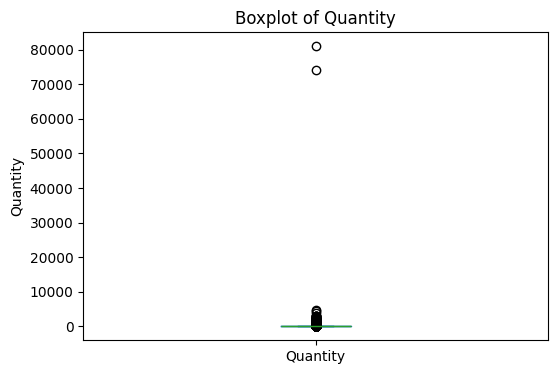

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df_all['Quantity'].plot(kind='box')
plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")
plt.show()

Most transactions involve small quantities, with the median around 3 items. However, there are many extreme outliers, with some transactions reaching very high quantities (up to around 80,000 units). These extreme values likely represent bulk or wholesale purchases.

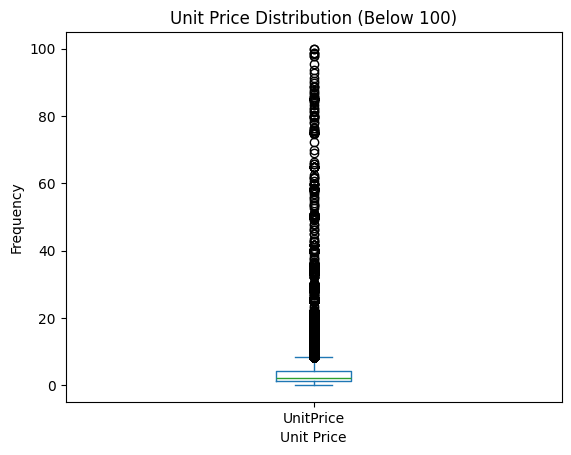

In [25]:
df_all[df_all['UnitPrice'] < 100]['UnitPrice'].plot(kind='box')
plt.title("Unit Price Distribution (Below 100)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

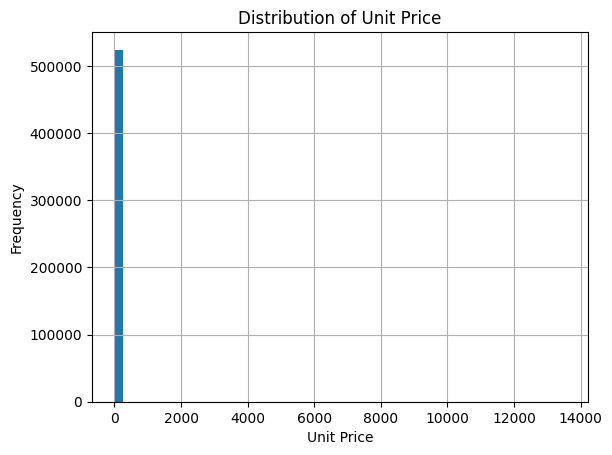

In [26]:
df_all['UnitPrice'].hist(bins=50)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

Most products have very low prices, mainly between £0.1 and £10. A very small number of products have extremely high prices, with the maximum reaching £13,541.33. Because of these few high-priced items, the distribution is highly right-skewed and most values appear compressed on the left side of the graph.

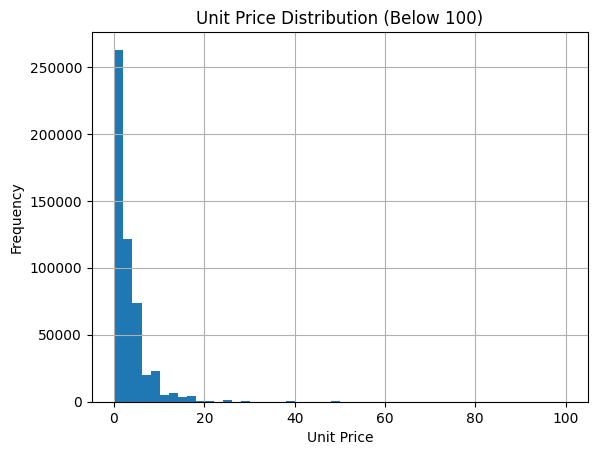

In [27]:
df_all[df_all['UnitPrice'] < 100]['UnitPrice'].hist(bins=50)
plt.title("Unit Price Distribution (Below 100)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

Most products are priced between £0.1 and £10, especially below £5. As the price increases, the number of products decreases, showing that high-priced items are rare.

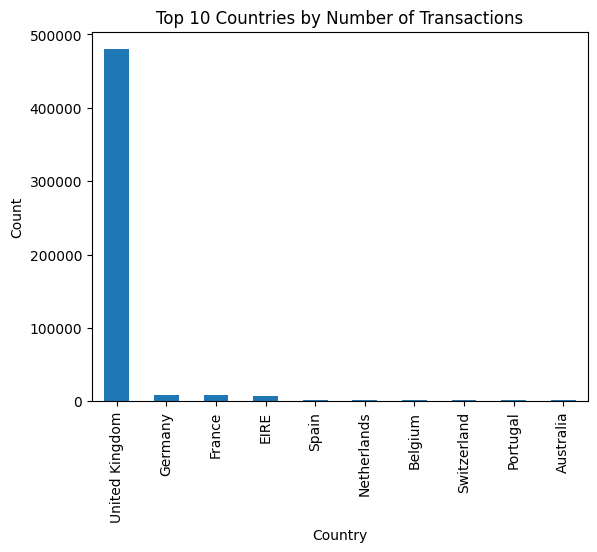

In [28]:
df_all['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries by Number of Transactions")
plt.ylabel("Count")
plt.show()

The majority of transactions come from the United Kingdom, which dominates the dataset compared to other countries. Countries like Germany, France, and EIRE contribute much fewer transactions. This shows that the business mainly operates in the UK, with limited international sales.

BIVARIATE ANALYSIS

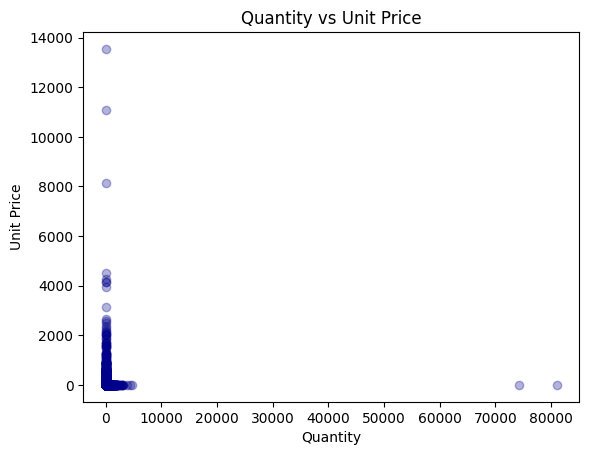

In [29]:
plt.scatter(df_all['Quantity'], df_all['UnitPrice'], alpha=0.3,color='darkblue')
plt.title("Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

scatter plot is compressed because of extreme values (Quantity = 80,995 and UnitPrice = 13,541).

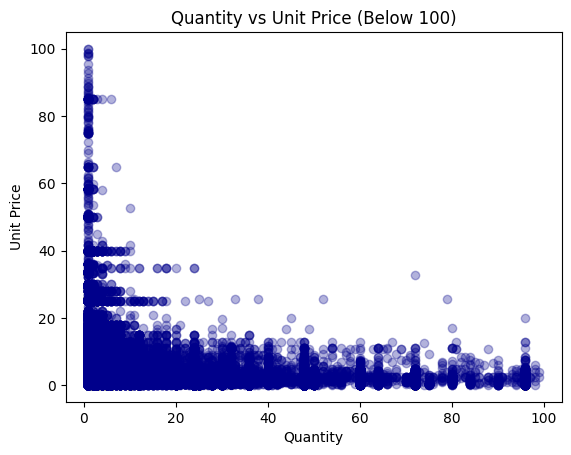

In [30]:
filtered_df = df_all[(df_all['Quantity'] < 100) & (df_all['UnitPrice'] < 100)]

plt.scatter(filtered_df['Quantity'], filtered_df['UnitPrice'], alpha=0.3, color='darkblue')
plt.title("Quantity vs Unit Price (Below 100)")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()

The scatter plot shows no clear correlation between Quantity and UnitPrice. Most sales are concentrated in low quantity and low price ranges, indicating that bulk purchases do not always involve higher-priced products.

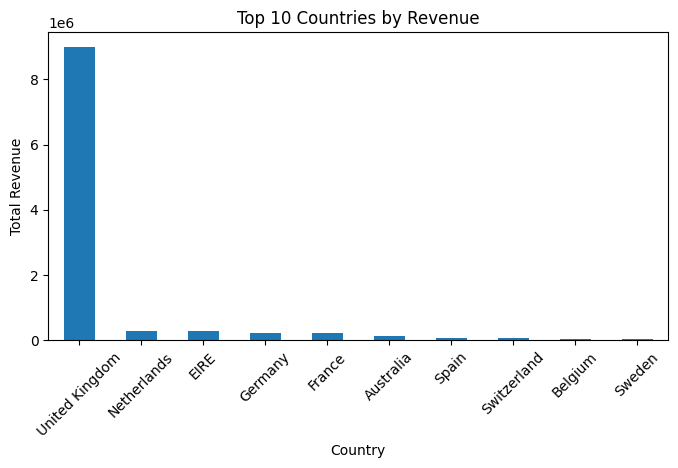

In [31]:
plt.figure(figsize=(8,4))
df_all.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

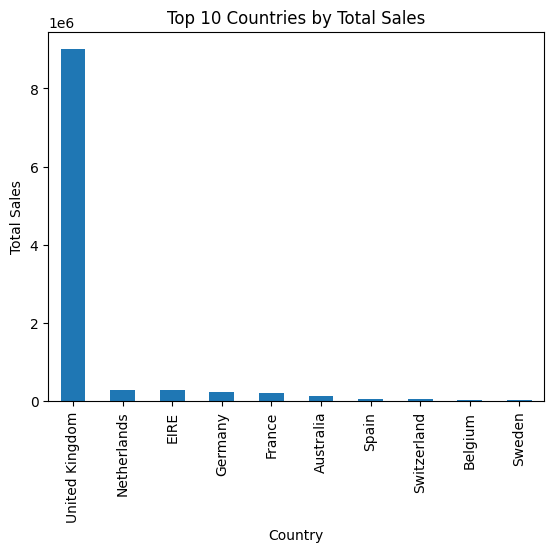

In [36]:
top_countries = df_all.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Total Sales")
plt.ylabel("Total Sales")
plt.show()

MULTIVARIATE ANALYSIS

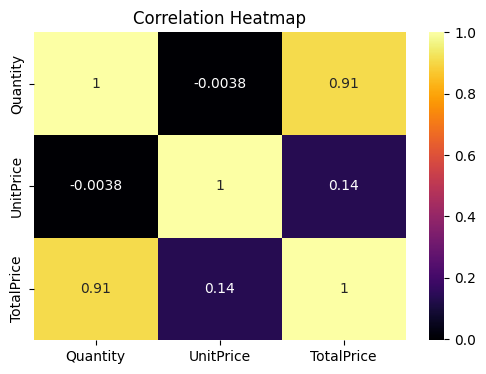

In [33]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df_all[['Quantity','UnitPrice','TotalPrice']].corr(),
            annot=True, cmap='inferno')
plt.title("Correlation Heatmap")
plt.show()

PRODUCT ANALYSIS

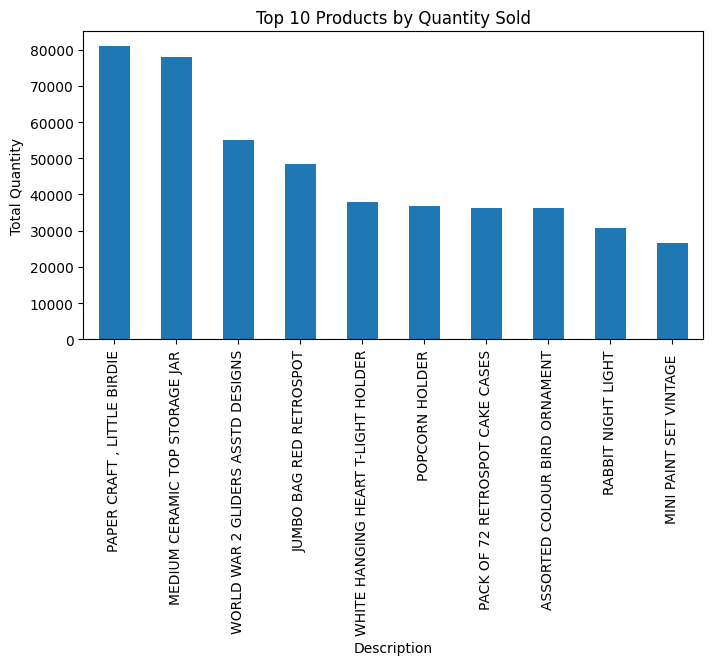

In [33]:
top_products_qty = df_all.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
top_products_qty.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.ylabel("Total Quantity")
plt.xticks(rotation=90)
plt.show()

Paper Craft Little Birdie and Medium Ceramic Top Storage Jar are the most sold products, with the highest quantities. This shows these items are very popular among customers.

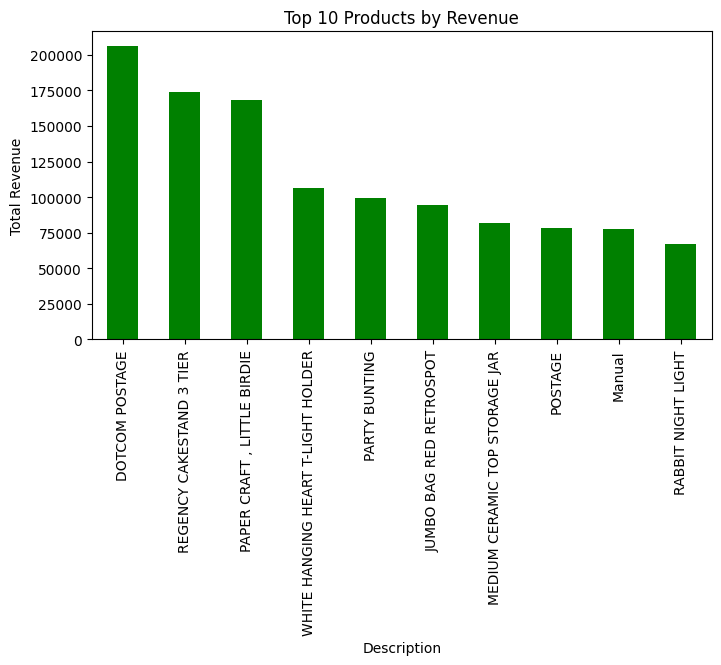

In [43]:
top_products_revenue = df_all.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
top_products_revenue.plot(kind='bar',color='green')
plt.title("Top 10 Products by Revenue")
plt.ylabel("Total Revenue")
plt.show()


The chart shows the top 10 products that generate the highest revenue. DOTCOM POSTAGE generates the most revenue, followed by REGENCY CAKESTAND 3 TIER and PAPER CRAFT, LITTLE BIRDIE.

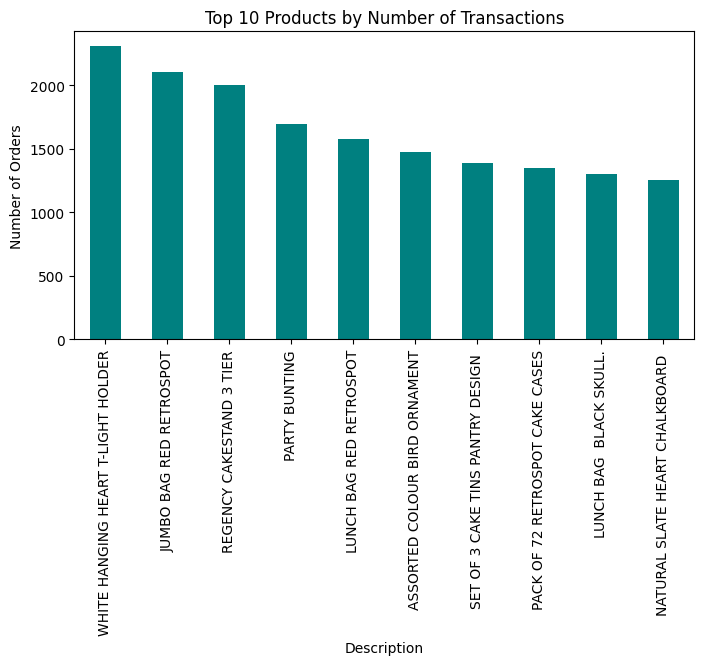

In [41]:
top_products_count = df_all['Description'].value_counts().head(10)

plt.figure(figsize=(8,4))
top_products_count.plot(kind='bar',color='teal')
plt.title("Top 10 Products by Number of Transactions")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)
plt.show()

The chart shows the top 10 products by number of transactions. White Hanging Heart T-Light Holder has the highest number of orders, followed by Jumbo Bag Red Retrospot and Regency Cakestand 3 Tier.

In [ ]:
SALES ANALYSIS

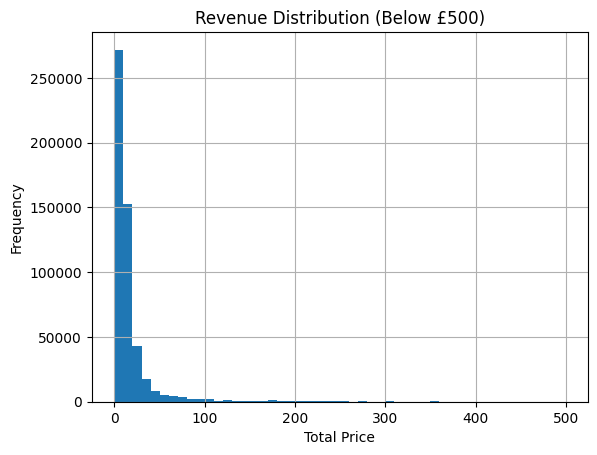

In [35]:
df_all[df_all['TotalPrice'] < 500]['TotalPrice'].hist(bins=50)
plt.title("Revenue Distribution (Below £500)")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

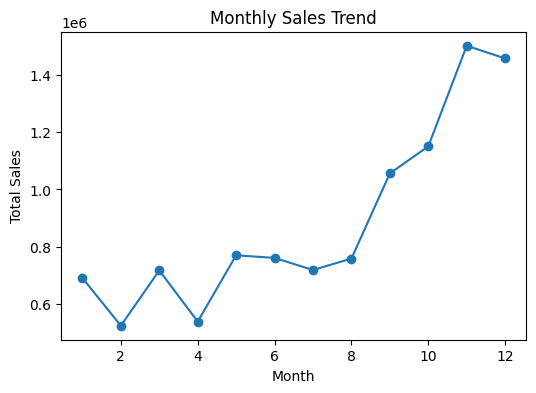

In [36]:
monthly_sales = df_all.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(6,4))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

The monthly sales trend shows that sales gradually increase towards the end of the year. The highest sales occur in November and December, indicating higher customer purchases during this period

In [ ]:
TIMES ANALYSIS

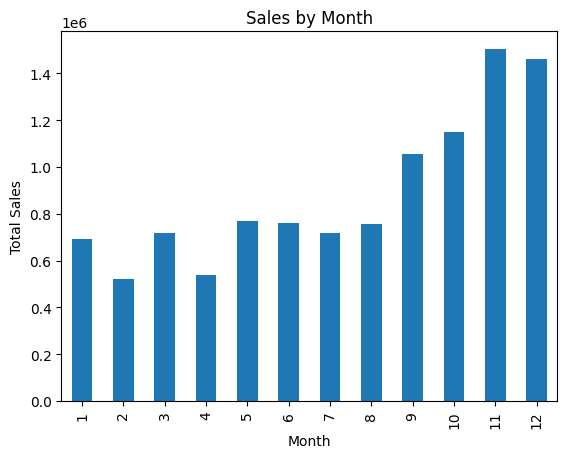

In [32]:
df_all.groupby('Month')['TotalPrice'].sum().plot(kind='bar')
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

The sales by month chart shows that sales increase toward the end of the year. The highest sales occur in November and December, while February and April have comparatively lower sales. This indicates that the business experiences higher demand during the year-end period

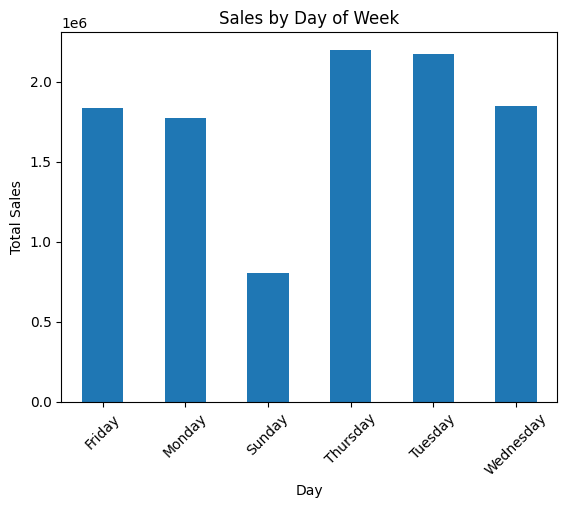

In [37]:
df_all.groupby('DayOfWeek')['TotalPrice'].sum().plot(kind='bar')
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

The chart shows that sales vary across different days of the week. The highest sales occur on Thursday and Tuesday, while Sunday has the lowest sales. This indicates that customer purchases are higher during weekdays compared to Sunday.

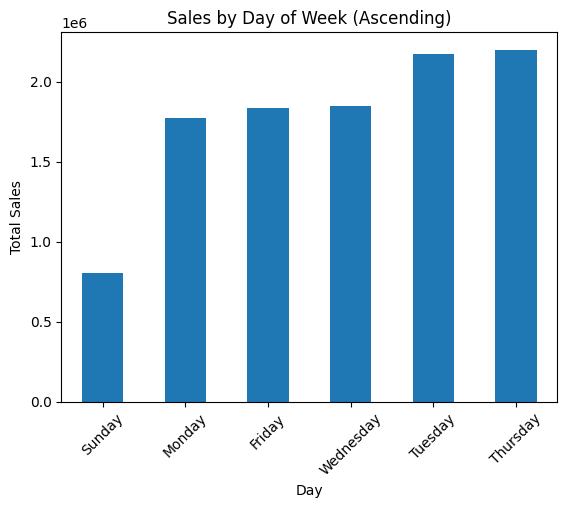

In [42]:
day_sales = df_all.groupby('DayOfWeek')['TotalPrice'].sum().sort_values()
day_sales.plot(kind='bar')
plt.title("Sales by Day of Week (Ascending)")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

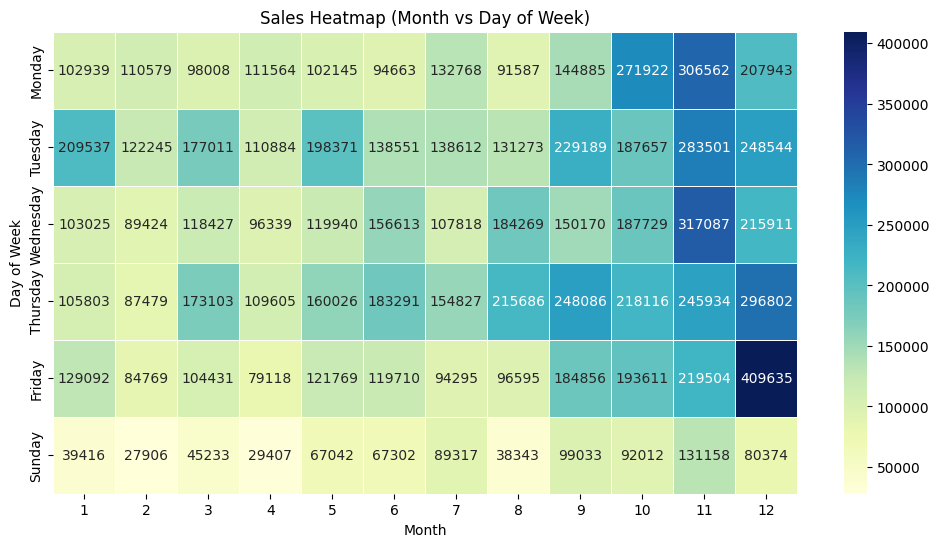

In [43]:
import seaborn as sns
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
pivot_table = df_all.pivot_table(values='TotalPrice',index='DayOfWeek',columns='Month',aggfunc='sum')
pivot_table = pivot_table.reindex(day_order)
plt.figure(figsize=(12,6))
sns.heatmap(pivot_table,cmap='YlGnBu',annot=True,fmt='.0f',linewidths=0.5)
plt.title("Sales Heatmap (Month vs Day of Week)")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.show()

The heatmap shows that sales increase towards the end of the year, especially in November and December, with higher activity on weekdays like Tuesday and Thursday.

In [ ]:
CUSTOMER ANALYSIS

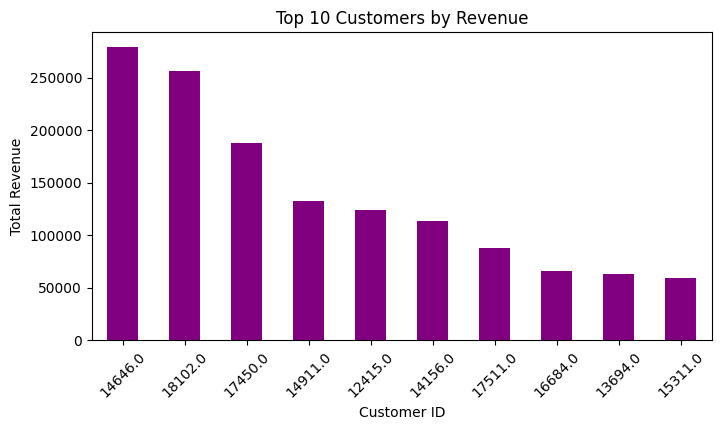

In [49]:
top_customers = df_cust.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
top_customers.plot(kind='bar', color='purple')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

Certain customers generate significantly higher revenue than others. Customer 14646 contributes the highest revenue, showing that a few high-value customers play an important role in total sales.

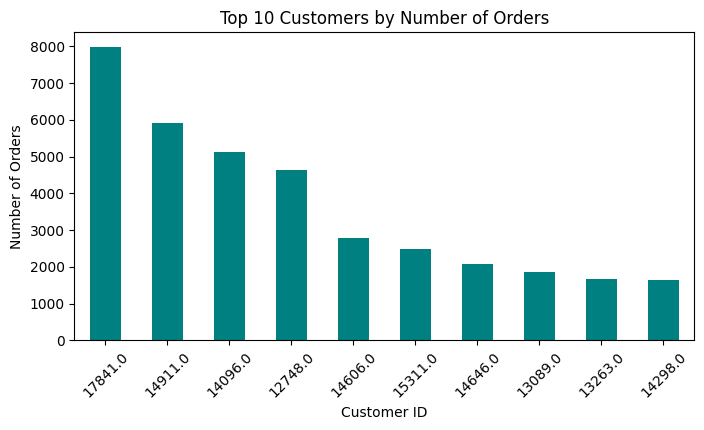

In [50]:
top_orders = df_cust['CustomerID'].value_counts().head(10)
plt.figure(figsize=(8,4))
top_orders.plot(kind='bar', color='teal')
plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Some customers place orders more frequently than others. Customer 17841 has the highest number of orders, indicating a highly active or loyal customer who contributes many transactions.

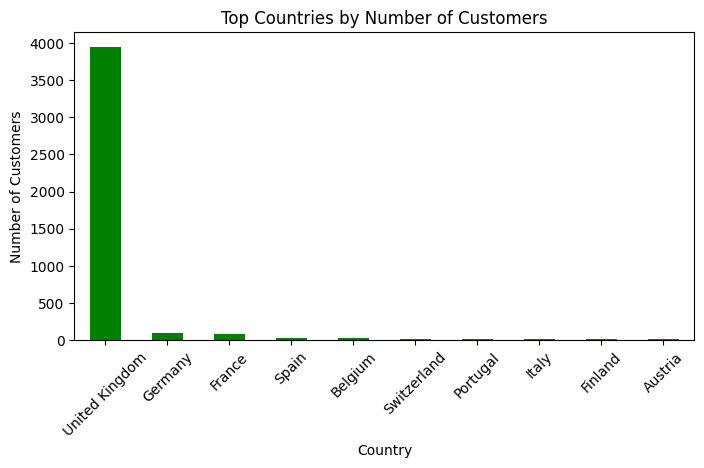

In [56]:
customer_country = df_cust.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4))
customer_country.plot(kind='bar', color='green')

plt.title("Top Countries by Number of Customers")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

The majority of customers are from the United Kingdom, while other countries such as Germany and France contribute a much smaller number of customers. This shows that the business is mainly concentrated in the UK market.

BUSINESS INSIGHTS
1. Low-priced products dominate sales
Most products are priced below £10, indicating that the business mainly sells affordable items. For example, many items such as decorative gifts and small household products are sold at lower prices.
2. A few products drive most sales
Some products generate significantly higher sales than others. For example, Paper Craft Little Birdie and Regency Cakestand 3 Tier are among the most popular products with very high sales quantities.
3. High-value customers contribute significant revenue
A small number of customers generate a large portion of the total revenue. For example, Customer 14646 contributes the highest revenue compared to other customers.
4. Sales increase toward the end of the year
Monthly sales analysis shows that November and December have the highest sales, indicating higher demand during the holiday and festive season.
5. The United Kingdom dominates the customer base
Most customers and transactions come from the United Kingdom, while countries like Germany and France contribute a smaller number of customers.
6. Most transactions are small purchases
Revenue distribution shows that most transactions generate low sales values (below £50), while only a few transactions produce very high revenue.m